# Training Computer Vision Models

## Loading Database

In [1]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

def get_dataloaders(data_dir,
                    train_dir='train',
                    test_dir='test',
                    batch_size=32,
                    image_size=224,
                    mean=None,
                    std=None,
                    num_workers=0,
                    pin_memory=True):
    """
    Returns train, val, and test DataLoaders using ImageFolder layout:
      data_dir/train/<class>/*.jpg
      data_dir/test/<class>/*.jpg (split 50/50 into val and test)

    Defaults to ImageNet normalization if mean/std not provided.
    """
    if mean is None:
        mean = [0.485, 0.456, 0.406]
    if std is None:
        std = [0.229, 0.224, 0.225]

    # Ensure small images are upscaled before cropping to avoid size errors
    train_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.RandomResizedCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_path = os.path.join(data_dir, train_dir)
    test_path = os.path.join(data_dir, test_dir)

    train_dataset = datasets.ImageFolder(train_path, transform=train_transforms)
    full_test_dataset = datasets.ImageFolder(test_path, transform=val_transforms)
    
    # Split test dataset 50/50 into validation and test
    total_test_samples = len(full_test_dataset)
    indices = list(range(total_test_samples))
    split_idx = total_test_samples // 2
    
    val_indices = indices[:split_idx]
    test_indices = indices[split_idx:]
    
    val_dataset = Subset(full_test_dataset, val_indices)
    test_dataset = Subset(full_test_dataset, test_indices)

    train_loader = DataLoader(train_dataset,
                              batch_size=batch_size,
                              shuffle=True,
                              num_workers=num_workers,
                              pin_memory=pin_memory)
    
    val_loader = DataLoader(val_dataset,
                            batch_size=batch_size,
                            shuffle=False,
                            num_workers=num_workers,
                            pin_memory=pin_memory)
    
    test_loader = DataLoader(test_dataset,
                             batch_size=batch_size,
                             shuffle=False,
                             num_workers=num_workers,
                             pin_memory=pin_memory)
    
    return train_loader, val_loader, test_loader, train_dataset.classes

In [2]:
train_loader, val_loader, test_loader, classes = get_dataloaders('../data/Nutrition_dataset', batch_size=32, image_size=224)

print(f"Train samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")

Train samples: 7056
Test samples: 882
Validation samples: 882


## Optimizing Hyperparemeters

In [3]:
import optuna
import sys
sys.path.append("../")
import importlib
from utils import image_models
importlib.reload(image_models)
import torch
import torch.nn as nn

c:\Users\gnoceras\Documents\HackIL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Use existing loaders and class list
subset_fraction = 0.2
num_classes = len(classes)

train_dataset = train_loader.dataset
val_dataset = val_loader.dataset

train_indices = torch.randperm(len(train_dataset))[: int(len(train_dataset) * subset_fraction)]
val_indices = list(range(len(val_dataset)))[:int(len(val_dataset) * subset_fraction)]

train_subset_optuna = torch.utils.data.Subset(train_dataset, train_indices)
val_subset_optuna = torch.utils.data.Subset(val_dataset, val_indices)

train_loader_optuna = DataLoader(
    train_subset_optuna,
    batch_size=train_loader.batch_size,
    shuffle=True,
    num_workers=train_loader.num_workers,
    pin_memory=train_loader.pin_memory,
)

val_loader_optuna = DataLoader(
    val_subset_optuna,
    batch_size=val_loader.batch_size,
    shuffle=False,
    num_workers=val_loader.num_workers,
    pin_memory=val_loader.pin_memory,
)

print(f"Number of training batches: {len(train_loader_optuna)}")
print(f"Number of validation batches: {len(val_loader_optuna)}")


def _build_mobilevit(variant: str, num_classes: int):
    # Try direct num_classes support first
    try:
        return image_models.MobileViT(model_name=variant, num_classes=num_classes).to(device)
    except TypeError:
        model = image_models.MobileViT(model_name=variant).to(device)

        # Fallback: replace final classifier layer if present
        if hasattr(model, "classifier"):
            if isinstance(model.classifier, nn.Linear):
                model.classifier = nn.Linear(model.classifier.in_features, num_classes).to(device)
            elif isinstance(model.classifier, nn.Sequential) and isinstance(model.classifier[-1], nn.Linear):
                in_features = model.classifier[-1].in_features
                model.classifier[-1] = nn.Linear(in_features, num_classes).to(device)
        return model

def _build_mobilenet(variant: str, num_classes: int):
    # Try direct num_classes support first
    try:
        return image_models.MobileNetV3(model_name=variant, num_classes=num_classes).to(device)
    except TypeError:
        model = image_models.MobileNetV3(model_name=variant).to(device)

        # Fallback: replace final classifier layer if present
        if hasattr(model, "classifier"):
            if isinstance(model.classifier, nn.Linear):
                model.classifier = nn.Linear(model.classifier.in_features, num_classes).to(device)
            elif isinstance(model.classifier, nn.Sequential) and isinstance(model.classifier[-1], nn.Linear):
                in_features = model.classifier[-1].in_features
                model.classifier[-1] = nn.Linear(in_features, num_classes).to(device)
        return model


def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    """ mobilevit_variant = trial.suggest_categorical(
        "mobilevit_variant",
        ["mobilevit_s", "mobilevit_xs", "mobilevit_xxs"]
    ) 
    model = _build_mobilevit(mobilevit_variant, num_classes)"""

    mobilenet_variant = trial.suggest_categorical(
        "mobilenet_variant",
        ["mobilenetv3_small_100", "mobilenetv3_large_100"]
    )
    model = _build_mobilenet(mobilenet_variant, num_classes)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

    num_epochs = 1
    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for x, y in train_loader_optuna:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * x.size(0)

        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in val_loader_optuna:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)

                running_val_loss += loss.item() * x.size(0)
                preds = torch.argmax(logits, dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        val_loss = running_val_loss / total
        val_acc = correct / total

        scheduler.step()
        trial.report(val_loss, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    trial.set_user_attr("val_acc", val_acc)
    return val_loss

Number of training batches: 45
Number of validation batches: 6


In [6]:
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=2,
        n_warmup_steps=0
    )
)
study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

[I 2026-03-07 01:56:12,785] A new study created in memory with name: no-name-090a85ff-5273-4a2d-992c-65d05c8bd4f8
Best trial: 0. Best value: 0.59773:   5%|▌         | 1/20 [00:09<03:05,  9.78s/it]

[I 2026-03-07 01:56:22,571] Trial 0 finished with value: 0.5977298373525793 and parameters: {'lr': 0.00046353382091788165, 'weight_decay': 1.1389324595476895e-05, 'mobilenet_variant': 'mobilenetv3_large_100'}. Best is trial 0 with value: 0.5977298373525793.


Best trial: 0. Best value: 0.59773:  10%|█         | 2/20 [00:18<02:39,  8.89s/it]

[I 2026-03-07 01:56:30,826] Trial 1 finished with value: 2.402582959695296 and parameters: {'lr': 3.386034836329488e-05, 'weight_decay': 1.3369880120545299e-06, 'mobilenet_variant': 'mobilenetv3_large_100'}. Best is trial 0 with value: 0.5977298373525793.


Best trial: 0. Best value: 0.59773:  15%|█▌        | 3/20 [00:25<02:17,  8.11s/it]

...

[I 2026-03-07 01:58:52,175] Trial 17 pruned. 


Best trial: 12. Best value: 0.510429:  95%|█████████▌| 19/20 [02:47<00:09,  9.22s/it]

[I 2026-03-07 01:59:00,477] Trial 18 pruned. 


Best trial: 12. Best value: 0.510429: 100%|██████████| 20/20 [02:56<00:00,  8.85s/it]

[I 2026-03-07 01:59:09,769] Trial 19 pruned. 


In [7]:
print("Best trial:")
print(study.best_trial.value)

print("Best params:")
for k, v in study.best_trial.params.items():
    print(f"{k}: {v}")

Best trial:
0.5104286480610344
Best params:
lr: 0.0009460910094779379
weight_decay: 8.241164057296425e-06
mobilenet_variant: mobilenetv3_large_100


**Best hyperparameters - MobileViT:**

lr: 0.0007046396368945212

weight_decay: 1.0105437685712708e-06

mobilevit_variant: mobilevit_s

**Best hyperparameters - MobileNetv3:**

lr: 0.0009460910094779379

weight_decay: 8.241164057296425e-06

mobilenet_variant: mobilenetv3_large_100

In [8]:
torch.cuda.empty_cache()

## Training the model

In [9]:
num_classes = len(classes)

""" model = image_models.MobileViT(
    model_name=study.best_trial.params["mobilevit_variant"],
    num_classes=num_classes
).to(device) """

model = image_models.MobileNetV3(
    model_name=study.best_trial.params["mobilenet_variant"],
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=study.best_trial.params["lr"],
    weight_decay=study.best_trial.params["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

scaler = torch.amp.GradScaler("cuda")

num_epochs = 50
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
modelName = "MobileViT"

# Track losses for plotting
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_train_loss = 0.0
    train_samples = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast("cuda"):
            logits = model(x)
            loss = criterion(logits, y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_train_loss += loss.item() * x.size(0)
        train_samples += x.size(0)
    
    train_loss = running_train_loss / train_samples
    
    # Validation phase
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            
            with torch.amp.autocast("cuda"):
                logits = model(x)
                loss = criterion(logits, y)
            
            running_val_loss += loss.item() * x.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += x.size(0)
    
    val_loss = running_val_loss / total
    val_acc = correct / total
    
    # Track losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | Acc: {val_acc:.4f}"
    )

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        print(f"Validation loss improved. Saving model at epoch {epoch+1} ✅")
        torch.save(model.state_dict(), f"../models/{modelName}.pth")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epochs. ❌")
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1} 🛑")
            break

Epoch [1/50] Train: 0.8453 | Val: 0.3209 | Acc: 0.9116
Validation loss improved. Saving model at epoch 1 ✅
Epoch [2/50] Train: 0.4169 | Val: 0.0910 | Acc: 0.9739
Validation loss improved. Saving model at epoch 2 ✅
Epoch [3/50] Train: 0.7764 | Val: 0.1416 | Acc: 0.9592
No improvement for 1 epochs. ❌
Epoch [4/50] Train: 0.5555 | Val: 1.6890 | Acc: 0.9104
No improvement for 2 epochs. ❌
Epoch [5/50] Train: 0.4331 | Val: 0.0910 | Acc: 0.9728
Validation loss improved. Saving model at epoch 5 ✅
Epoch [6/50] Train: 0.2180 | Val: 0.0400 | Acc: 0.9875
Validation loss improved. Saving model at epoch 6 ✅
Epoch [7/50] Train: 0.1646 | Val: 0.0393 | Acc: 0.9875
Validation loss improved. Saving model at epoch 7 ✅
Epoch [8/50] Train: 0.2056 | Val: 0.0303 | Acc: 0.9887
Validation loss improved. Saving model at epoch 8 ✅
Epoch [9/50] Train: 0.1864 | Val: 0.0834 | Acc: 0.9649
No improvement for 1 epochs. ❌
Epoch [10/50] Train: 0.1451 | Val: 0.0339 | Acc: 0.9864
No improvement for 2 epochs. ❌
Epoch [11/50]

### Visualizing training history

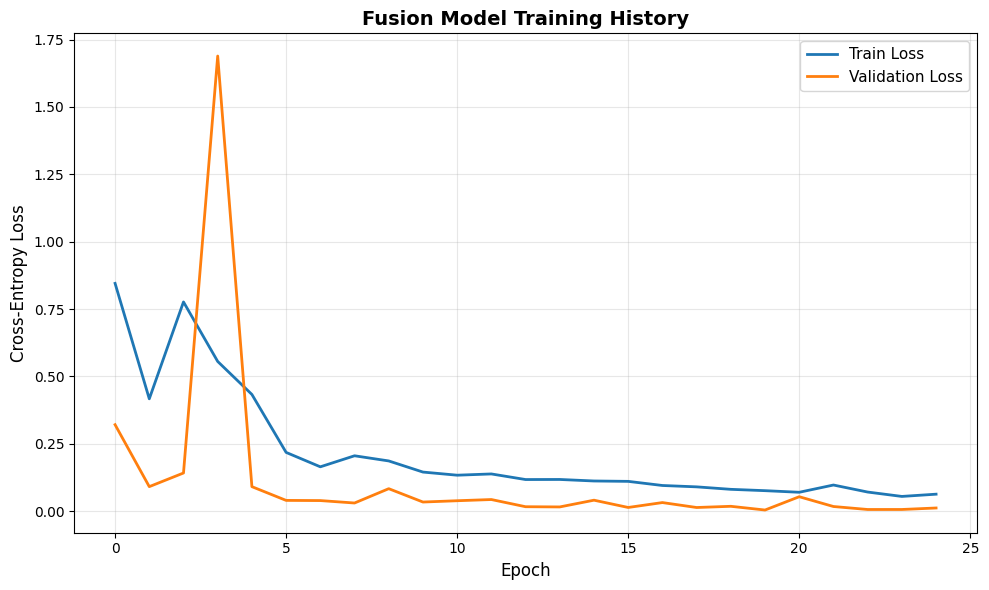

Final train loss: 0.063039
Final validation loss: 0.011796
Best validation loss: 0.004250


In [10]:
import matplotlib.pyplot as plt

# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.title('Fusion Model Training History', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")
print(f"Best validation loss: {best_val_loss:.6f}")

## Evaluating Model

In [11]:
import numpy as np

# Load the best model
model.load_state_dict(torch.load(f"../models/{modelName}.pth"))
model.eval()

# Get all predictions and true labels from TEST set
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        
        with torch.amp.autocast("cuda"):
            logits = model(x)
        
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print(f"Evaluated on {len(all_labels)} test samples")

Evaluated on 882 test samples


### Confusion Matrix

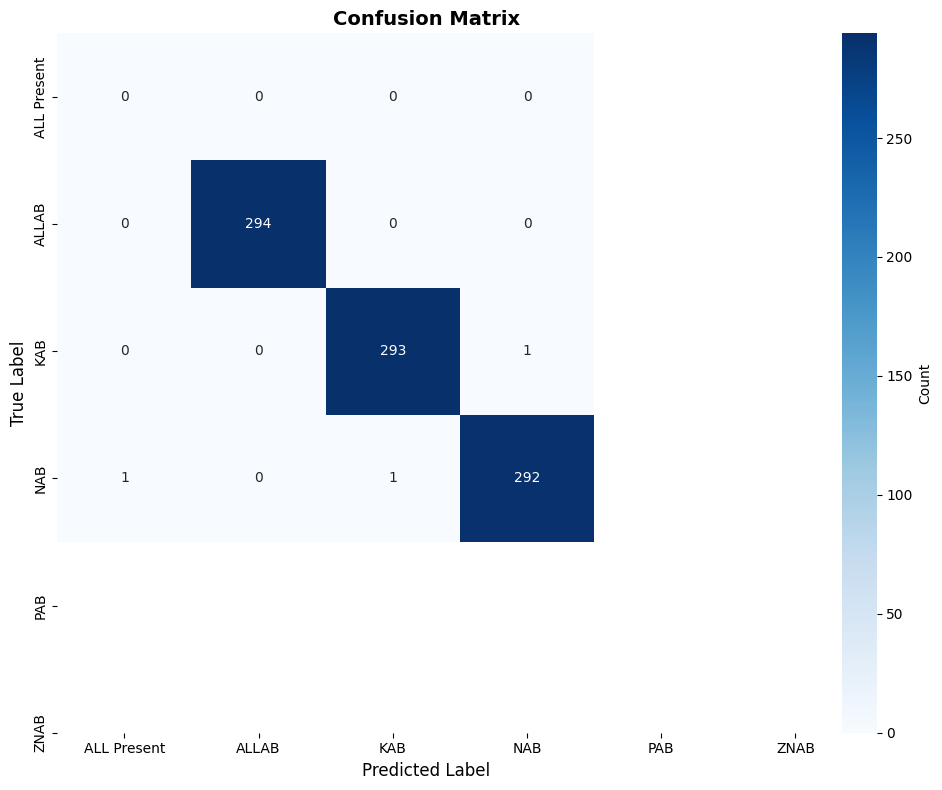

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Random Test Predictions

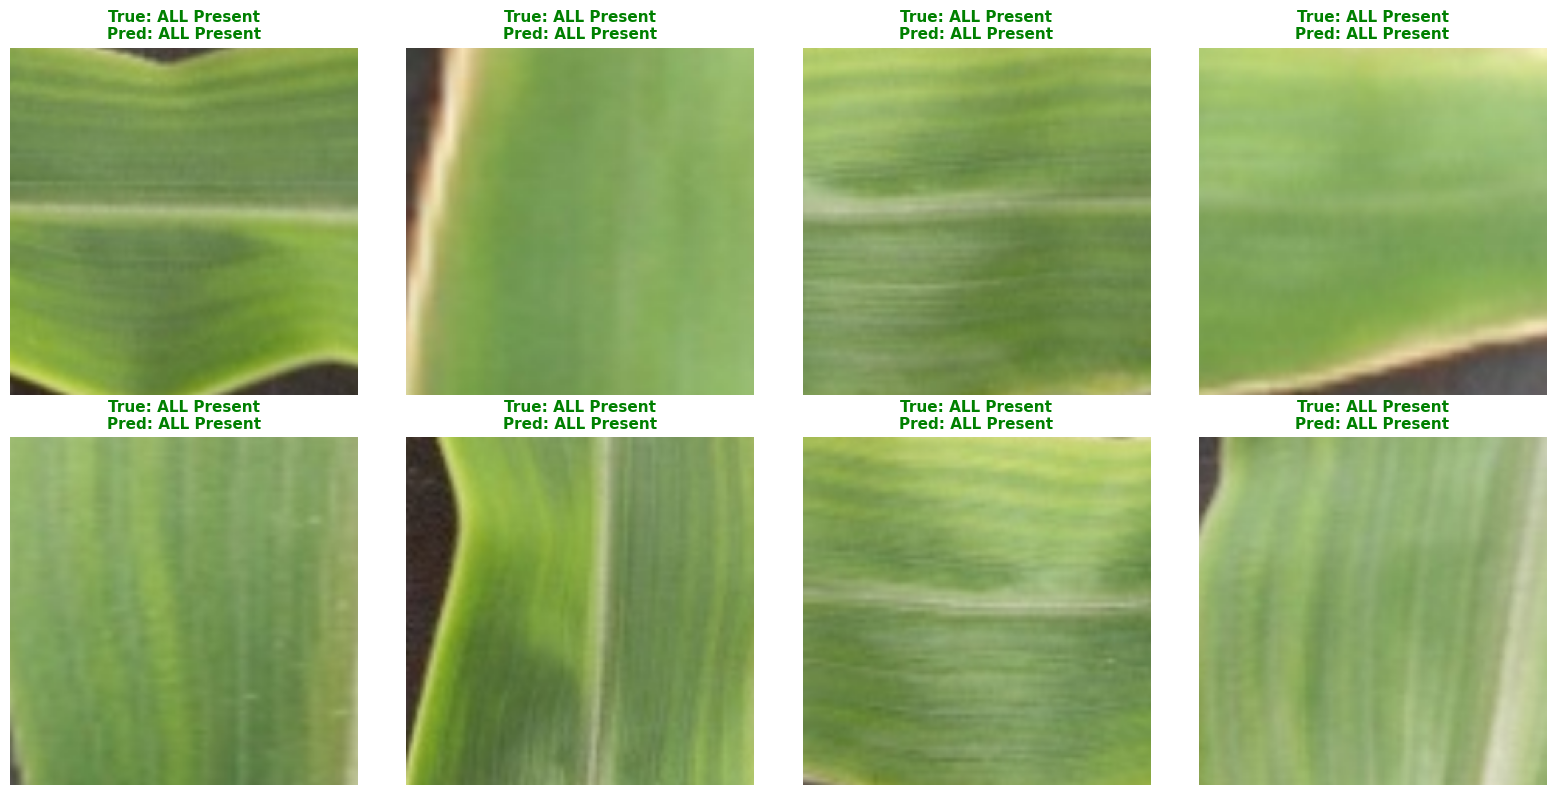

In [ ]:
import random

# Get a batch of test images
test_iter = iter(test_loader)
images, labels = next(test_iter)

# Select random indices
num_samples = min(8, len(images))
random_indices = random.sample(range(len(images)), num_samples)

# Predict
images_device = images[random_indices].to(device)
with torch.no_grad():
    with torch.amp.autocast("cuda"):
        logits = model(images_device)
    predictions = torch.argmax(logits, dim=1)

# Denormalize images for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Plot predictions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, ax in enumerate(axes[:num_samples]):
    img = images[random_indices[idx]].cpu()
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    img = img.permute(1, 2, 0).numpy()
    
    true_label = classes[labels[random_indices[idx]]]
    pred_label = classes[predictions[idx].cpu()]
    
    ax.imshow(img)
    ax.axis('off')
    
    # Color code: green for correct, red for incorrect
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', 
                 fontsize=11, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

### Getting Metrics

In [16]:
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# Overall metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

print("=" * 60)
print("OVERALL METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\n")

# Per-class metrics
print("=" * 60)
print("PER-CLASS METRICS")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

OVERALL METRICS
Accuracy:  0.9972
Precision: 0.9972
Recall:    0.9972
F1-Score:  0.9972


PER-CLASS METRICS
              precision    recall  f1-score   support

 ALL Present     0.9966    0.9966    0.9966       294
       ALLAB     1.0000    0.9966    0.9983       294
         KAB     0.9966    1.0000    0.9983       294
         NAB     1.0000    1.0000    1.0000       294
         PAB     0.9966    0.9966    0.9966       294
        ZNAB     0.9932    0.9932    0.9932       294

    accuracy                         0.9972      1764
   macro avg     0.9972    0.9972    0.9972      1764
weighted avg     0.9972    0.9972    0.9972      1764

